In [ ]:
# 1. แตกไฟล์ Dataset ที่เราอัปโหลดขึ้นไป
import zipfile
import os

with zipfile.ZipFile('/content/dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset_unzipped')

print("แตกไฟล์เรียบร้อย!")

แตกไฟล์เรียบร้อย!


In [ ]:
# 2. นำเข้า Library ที่ต้องใช้
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np


Using DATA_DIR: dataset_unzipped/dataset
Found 400 images belonging to 5 classes.
Found 100 images belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 425ms/step - accuracy: 0.2150 - loss: 1.6169 - val_accuracy: 0.2500 - val_loss: 1.5870
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.3000 - loss: 1.5639 - val_accuracy: 0.5500 - val_loss: 1.5389
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.4550 - loss: 1.4775 - val_accuracy: 0.5200 - val_loss: 1.4199
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5475 - loss: 1.2717 - val_accuracy: 0.6400 - val_loss: 1.2150
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6175 - loss: 1.1007 - val_accuracy: 0.6600 - val_loss: 0.9683
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6825 - loss: 0.8558 - val_accuracy: 0.7700 - val_loss: 0.7219
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7625 - loss: 0.7208 - val_accuracy: 0.8900 - val_loss: 0.5987
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8250 - loss: 0.5607 - val_accuracy: 0.8800 -

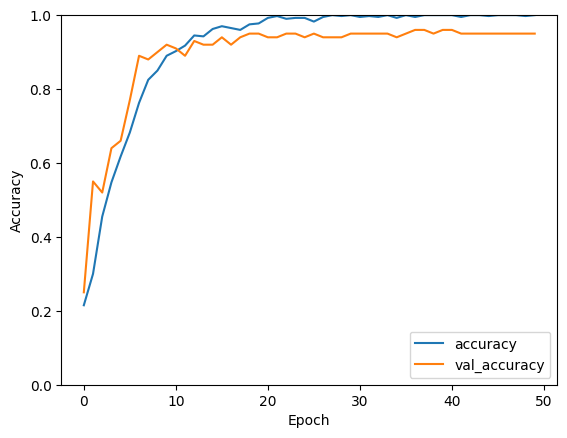

--- บันทึกโมเดลสำเร็จ! ดาวน์โหลดไฟล์ thai_digit_model.h5 ไปใช้ต่อได้เลย ---


In [ ]:
# 3. ตั้งค่าการดึงข้อมูลภาพ (Data Preprocessing)
# ปรับขนาดภาพเป็น 28x28 พิกเซล และ Normalization ให้ค่าสีเป็น 0-1
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # แบ่งข้อมูล 20% ไว้ทดสอบความแม่นยำ
)

DATA_DIR_BASE = 'dataset_unzipped' # ตรวจสอบชื่อโฟลเดอร์ข้างใน zip ให้ตรงกัน

# Dynamically adjust DATA_DIR if there's a single subdirectory
import os
subdirs = [d for d in os.listdir(DATA_DIR_BASE) if os.path.isdir(os.path.join(DATA_DIR_BASE, d))]
if len(subdirs) == 1 and subdirs[0] != '__MACOSX': # Exclude common macOS metadata folder
    DATA_DIR = os.path.join(DATA_DIR_BASE, subdirs[0])
else:
    DATA_DIR = DATA_DIR_BASE # Use base if no single subdir or multiple
print(f"Using DATA_DIR: {DATA_DIR}")

train_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(28, 28),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(28, 28),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# 4. สร้างโครงสร้างโมเดล CNN (Convolutional Neural Network)
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # ป้องกัน Overfitting
    layers.Dense(5, activation='softmax') # 5 คลาส คือ ๓๑, ๓๒, ๓๓, ๓๔, ๓๕
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 5. เริ่มต้นการเทรน (Training)
# เพิ่ม epochs ตามต้องการเพื่อให้ accuracy เกิน 80%
history = model.fit(train_generator, epochs=50, validation_data=val_generator)

# 6. แสดงกราฟสรุปผล (ใช้ประกอบการนำเสนอได้)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

# 7. บันทึกโมเดลเป็นไฟล์ .h5
model.save('thai_digit_model.h5')
print("--- บันทึกโมเดลสำเร็จ! ดาวน์โหลดไฟล์ thai_digit_model.h5 ไปใช้ต่อได้เลย ---")